# Graph - co-occurrence of cell types on neighbouring channels

Visualisation of `graph_SUA_preprocess_new_filter.py`, for all four conditions:
RS and NATIM, unfiltered and quality-filtered.

**Edge colour is enrichment**, observed neighbouring pairs divided by the
permutation mean, so 1.0 is chance. Blue is depletion, red is enrichment.

**Edge thickness is the number of pairs tested**, log scaled. This is the
quantity that determines how well an enrichment value is estimated, and class
abundances differ by an order of magnitude, so it varies a lot. A strong colour
on a thin edge rests on few pairs and should be discounted. In the resting-state
data, for example, Positive units are only 28 of 2186, so Pos+Pos reaches an
enrichment of 6.2 on very little evidence.

Significance is not encoded in the graph. It is in the matrices and tables
further down, where it can be read alongside the counts rather than compressed
into a line style.

**Two null models**, both computed on the same observed counts:

`global` shuffles class labels across all units from all arrays, dates and
animals, preserving only the overall class composition. Sensitive to spatial
structure at every scale.

`within` shuffles only among the units on one array on one date, so each array
keeps its own composition. Tests local adjacency alone.

A pair enriched under `global` but not `within` shares cortical territory
rather than sitting on adjacent electrodes.

## Import

In [1]:
import os
os.chdir('/CSNG/studekat/ripple_paper_clean_copy/code_new_filter')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import seaborn as sns
from collections import defaultdict
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl

## Parameters

In [3]:
with open("/CSNG/studekat/ripple_paper_clean_copy/code_new_filter/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean_copy/dataframes_new_filter'
FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_analysis['colors_class']
CLASS_NAMES = params_analysis['classes_names']
CLASS_DICT = {'DOWN_narrow_shallow':'NarrBI','DOWN_narrow_sharp':'NarrTRI',
              'DOWN_wide':'Wide','DOWN_medium_shallow':'MedBI',
              'DOWN_medium_sharp':'MedTRI','UP':'Pos'}

all_pairs = list(itertools.combinations(FINAL_CLASSES, 2))
pairs_merged = ["+".join(sorted(t)) for t in all_pairs]
for cl in FINAL_CLASSES:
    pairs_merged.append("+".join((cl,cl)))

ALPHA = 0.05
SCOPES = ['global', 'within']

CONDITIONS = [
    ('RS',    None,      'RS all'),
    ('RS',    'pass_k3', 'RS filtered'),
    ('NATIM', None,      'NATIM all'),
    ('NATIM', 'pass_k3', 'NATIM filtered'),
]

# graph appearance
WIDTH_MODE = 'n_pairs'    # 'n_pairs' / 'n_close' / 'abs_z' / 'uniform'
W_MIN, W_MAX = 1.5, 9.0

## Data loading

Each preprocessing run writes to `dict_pair_occur_<TYPE>_<LEVEL>`. Missing
conditions are reported and skipped rather than raising, so the notebook runs
before every combination has been generated.

In [4]:
def load_condition(type_rec, quality_level):
    tag = f'{type_rec}' + (f'_{quality_level}' if quality_level else '_all')
    folder = f'{DF_FOLDER}/dict_pair_occur_{tag}'
    if not os.path.isdir(folder):
        print(f'   MISSING: {folder}')
        print(f'   -> run: python graph_SUA_preprocess_new_filter.py {type_rec}'
              + (f' {quality_level}' if quality_level else ''))
        return None
    out = {'folder': folder, 'tag': tag}
    for name in ['all_pairs_count','close_pairs_count','classes_counter','pooled_count']:
        with open(f'{folder}/{name}', 'rb') as f:
            out[name] = pickle.load(f)
    out['tables'] = {}
    for sc in SCOPES:
        p = f'{folder}/pair_enrichment_{sc}.csv'
        if os.path.isfile(p):
            out['tables'][sc] = pd.read_csv(p)
        else:
            print(f'   no table for scope {sc} in {tag}')
    with open(f'{folder}/meta', 'rb') as f:
        out['meta'] = pickle.load(f)
    return out


DATA = {}
for type_rec, ql, label in CONDITIONS:
    print(f'loading {label} ...')
    d = load_condition(type_rec, ql)
    if d is not None:
        DATA[label] = d
        m = d['meta']
        print(f"   {m['n_units']} units, {m['n_blocks']} blocks")
print()
print('loaded:', list(DATA.keys()))
missing = [lab for _,_,lab in CONDITIONS if lab not in DATA]
if missing:
    print('MISSING:', missing)

loading RS all ...
   1608 units, 68 blocks
loading RS filtered ...
   MISSING: /CSNG/studekat/ripple_paper_clean_copy/dataframes_new_filter/dict_pair_occur_RS_pass_k3
   -> run: python graph_SUA_preprocess_new_filter.py RS pass_k3
loading NATIM all ...
   9374 units, 294 blocks
loading NATIM filtered ...
   MISSING: /CSNG/studekat/ripple_paper_clean_copy/dataframes_new_filter/dict_pair_occur_NATIM_pass_k3
   -> run: python graph_SUA_preprocess_new_filter.py NATIM pass_k3

loaded: ['RS all', 'NATIM all']
MISSING: ['RS filtered', 'NATIM filtered']


In [5]:
rows = []
for label, d in DATA.items():
    r = {'condition': label, 'n_units': d['meta']['n_units'],
         'n_blocks': d['meta']['n_blocks']}
    for cl in FINAL_CLASSES:
        r[CLASS_DICT[cl]] = d['classes_counter'].get(cl, 0)
    rows.append(r)
df_units = pd.DataFrame(rows)
print(df_units.to_string(index=False))
print()
print('Class abundances differ by an order of magnitude, which is why edge')
print('thickness carries the pair count: a rare class gives a noisy enrichment.')

condition  n_units  n_blocks  NarrBI  MedBI  Wide  NarrTRI  MedTRI  Pos
   RS all     1608        68     214    527   462      157     179   69
NATIM all     9374       294    1398   2029  2799     1431    1058  659

Class abundances differ by an order of magnitude, which is why edge
thickness carries the pair count: a rare class gives a noisy enrichment.


## Graph plotting

In [6]:
def build_edge_data(cond, scope, weight_mode='enrichment', cross_only=True):
    """
    Returns {(class_a, class_b): (weight, p_value, n_close_obs, n_close_exp)}.

    weight_mode 'enrichment'  : observed / permutation mean, 1.0 = chance
    weight_mode 'probability' : close_sums / pooled_count, the original measure
    cross_only : omit same-class pairs, which the graph cannot draw as edges
    """
    tab = cond['tables'][scope].set_index('pair')
    pcol = 'p_holm' if 'p_holm' in tab.columns else 'p_perm'
    out = {}
    for pair in tab.index:
        a, b = pair.split('+')
        if cross_only and a == b:
            continue
        if weight_mode == 'enrichment':
            w = tab.loc[pair, 'enrichment']
        else:
            denom = cond['pooled_count'].get(pair, 0)
            w = (cond['close_pairs_count'][pair] / denom) if denom else 0.0
        out[(a, b)] = (float(w), float(tab.loc[pair, pcol]),
                       int(tab.loc[pair, 'n_close_obs']),
                       float(tab.loc[pair, 'n_close_exp']))
    return out


def _raw_width(cond, u, v, obs, exp, width_mode):
    """The untransformed quantity that thickness will encode."""
    if width_mode == 'n_pairs':
        return np.log10(cond['all_pairs_count'].get("+".join(sorted((u, v))), 0) + 1)
    if width_mode == 'n_close':
        return np.log10(obs + 1)
    if width_mode == 'abs_z':
        return abs((obs - exp) / np.sqrt(exp)) if exp > 0 else 0.0
    return 1.0


def plot_graph(edge_data, ax, title, cond, weight_mode='enrichment',
               width_mode=WIDTH_MODE, width_ref=None,
               vmin=None, vmax=None, show_cbar=True):
    """
    Circular graph. Colour is enrichment, diverging about 1. Thickness is the
    quantity named by width_mode, rescaled between W_MIN and W_MAX.

    width_ref, a (min, max) tuple of the raw quantity, lets several panels share
    one thickness scale so that they are directly comparable.
    """
    G = nx.Graph()
    for (u, v), (w, p, obs, exp) in edge_data.items():
        G.add_edge(u, v, weight=w, pval=p, n_close=obs,
                   raw_w=_raw_width(cond, u, v, obs, exp, width_mode))

    nodes = [c for c in FINAL_CLASSES if c in G.nodes()]
    n = len(nodes)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    radius = 0.1
    pos = {node: (radius*np.cos(a), radius*np.sin(a))
           for node, a in zip(nodes, angles)}
    node_colors = [CLASS_COLORS.get(node, 'gray') for node in nodes]

    ws = np.array([d['weight'] for _, _, d in G.edges(data=True)])
    if weight_mode == 'enrichment':
        span = max(abs(np.nanmax(ws) - 1), abs(1 - np.nanmin(ws)), 0.05)
        lo, hi = (1 - span, 1 + span) if vmin is None else (vmin, vmax)
        cmap = plt.cm.RdBu_r
    else:
        lo = 0 if vmin is None else vmin
        hi = np.nanmax(ws) if vmax is None else vmax
        cmap = plt.cm.binary
    norm = mpl.colors.Normalize(vmin=lo, vmax=hi)

    edges = list(G.edges())
    if width_mode == 'uniform':
        widths = [4.0] * len(edges)
    else:
        raw = np.array([G[u][v]['raw_w'] for u, v in edges], dtype=float)
        r_lo, r_hi = (raw.min(), raw.max()) if width_ref is None else width_ref
        if r_hi > r_lo:
            widths = W_MIN + (raw - r_lo) / (r_hi - r_lo) * (W_MAX - W_MIN)
        else:
            widths = [(W_MIN + W_MAX) / 2] * len(edges)

    nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=node_colors,
                           node_size=2000, ax=ax)
    cols = [cmap(norm(G[u][v]['weight'])) for u, v in edges]
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=cols,
                           width=list(widths), ax=ax)

    if show_cbar:
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, shrink=0.65, pad=0.02)
        cbar.set_label('enrichment (1 = chance)' if weight_mode=='enrichment'
                       else 'P(neighbouring)', fontsize=7)
        cbar.ax.tick_params(labelsize=6)

    ax.set_title(title, fontsize=9)
    for sp in ['right','left','top','bottom']:
        ax.spines[sp].set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.axis('equal')
    return len(edges)

In [7]:
# one thickness scale shared by every panel, so they are comparable
raw_all = []
for label, cond in DATA.items():
    for scope in SCOPES:
        if scope not in cond['tables']: continue
        for (u, v), (w, p, obs, exp) in build_edge_data(cond, scope).items():
            raw_all.append(_raw_width(cond, u, v, obs, exp, WIDTH_MODE))
WIDTH_REF = (min(raw_all), max(raw_all)) if raw_all and WIDTH_MODE != 'uniform' else None
print(f'thickness encodes: {WIDTH_MODE}, shared range {WIDTH_REF}')

thickness encodes: n_pairs, shared range (np.float64(2.5658478186735176), np.float64(4.315760490665735))


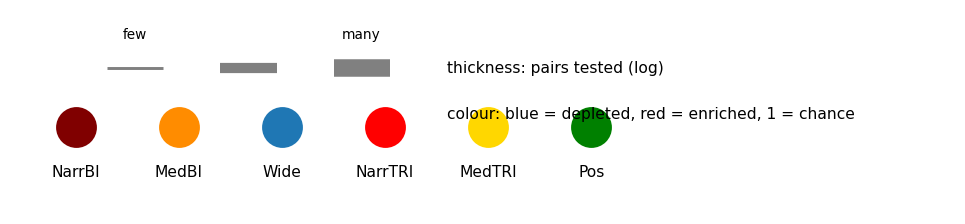

In [8]:
# legend
fig, ax = plt.subplots(figsize=(7,1.7), dpi=140)
for i, cl in enumerate(FINAL_CLASSES):
    ax.scatter(i, 0, s=400, color=CLASS_COLORS[cl])
    ax.text(i, -0.6, CLASS_DICT[cl], ha='center', fontsize=8)
for k, w in enumerate([W_MIN, (W_MIN+W_MAX)/2, W_MAX]):
    ax.plot([0.3+k*1.1, 0.85+k*1.1], [0.7, 0.7], color='gray', lw=w,
            solid_capstyle='butt')
ax.text(0.57, 1.05, 'few', ha='center', fontsize=7)
ax.text(2.77, 1.05, 'many', ha='center', fontsize=7)
LBL = {'n_pairs':'pairs tested (log)', 'n_close':'neighbouring pairs (log)',
       'abs_z':'|z| vs null', 'uniform':'constant'}
ax.text(3.6, 0.7, f'thickness: {LBL[WIDTH_MODE]}', va='center', fontsize=8)
ax.text(3.6, 0.15, 'colour: blue = depleted, red = enriched, 1 = chance',
        va='center', fontsize=8)
ax.set_xlim(-0.6, 8.5); ax.set_ylim(-1.0, 1.35)
ax.axis('off')
plt.tight_layout(); plt.show()

## Graphs, all conditions and both nulls

Rows are conditions, columns are the two null models.

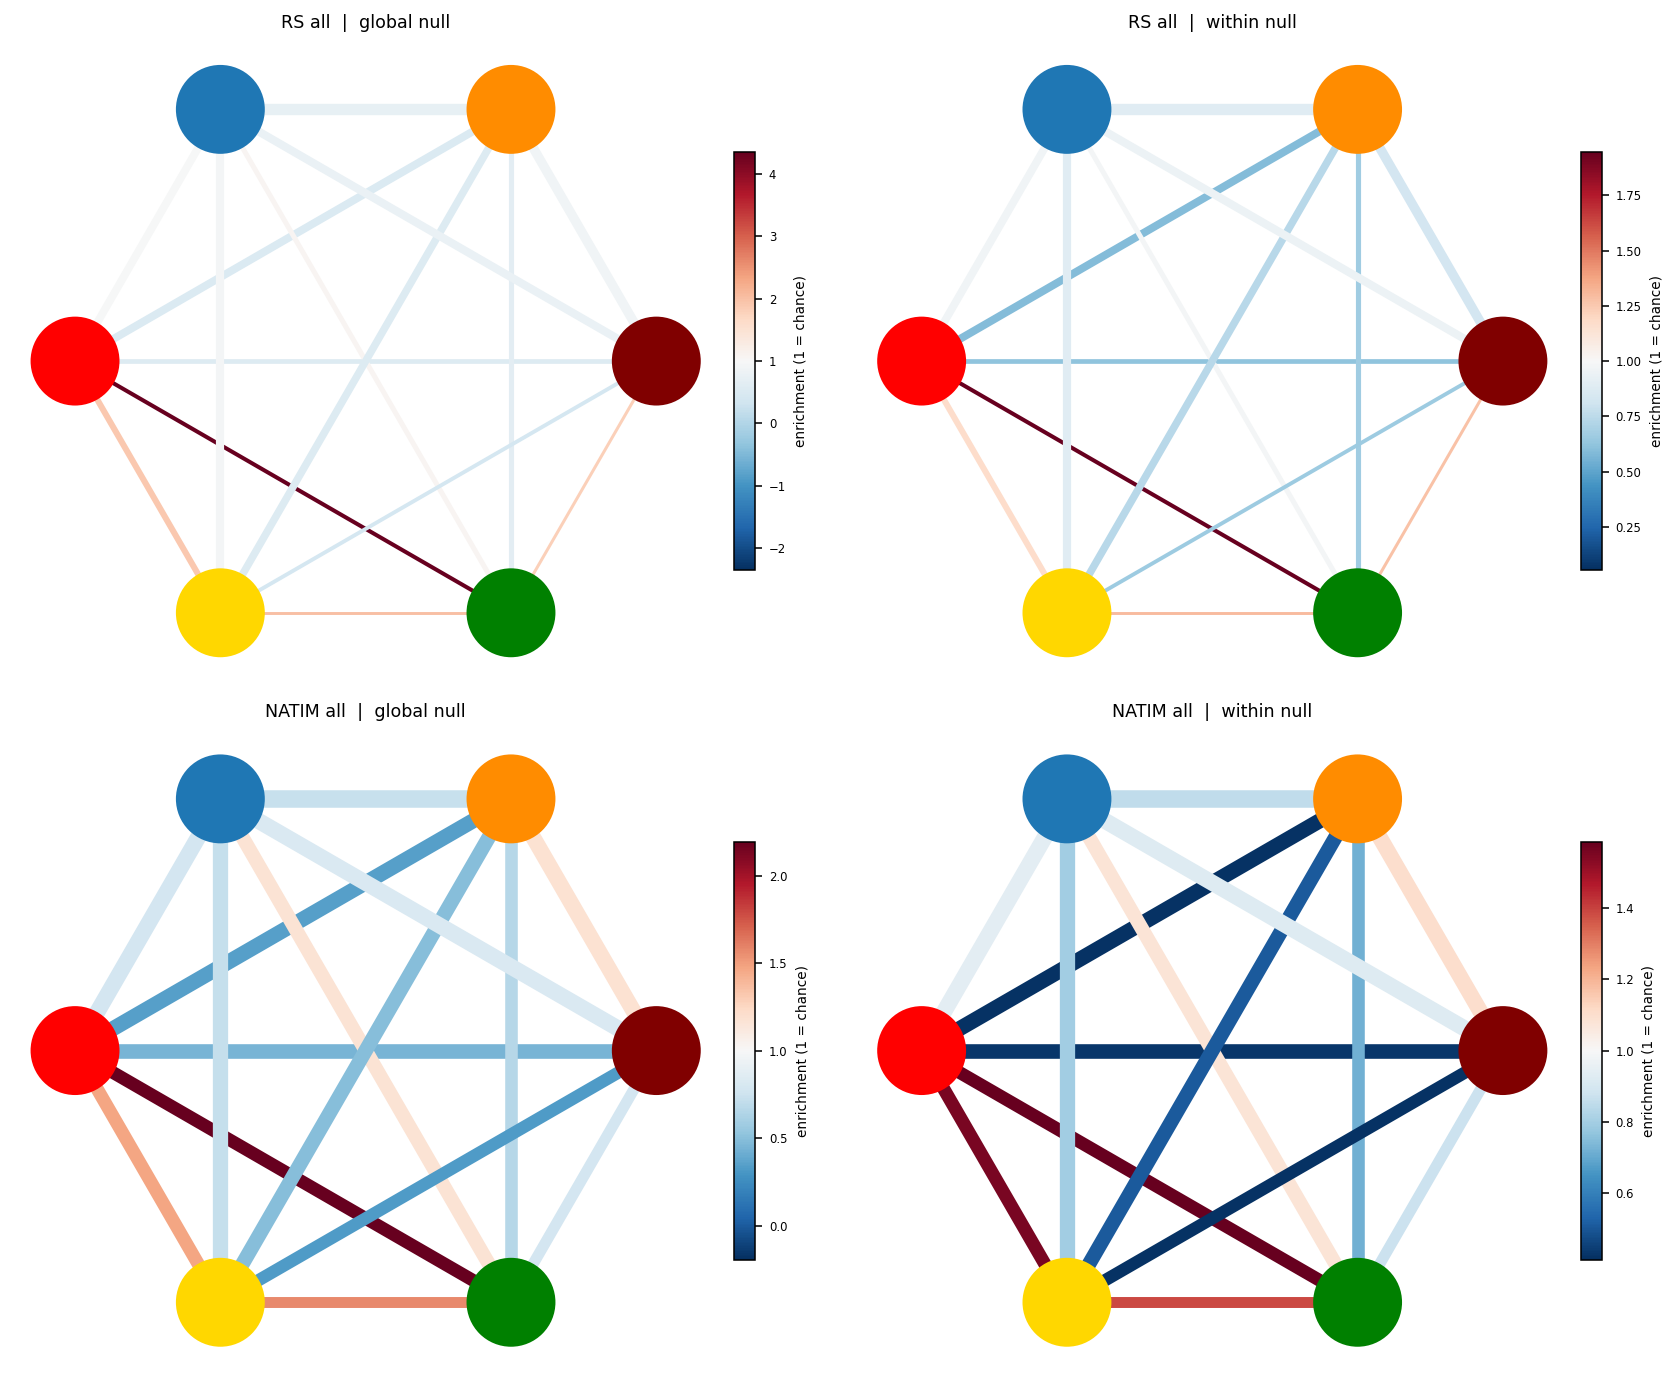

In [9]:
WEIGHT_MODE = 'enrichment'      # 'enrichment' or 'probability'

labels = list(DATA.keys())
n_rows = len(labels)
fig, axes = plt.subplots(n_rows, len(SCOPES),
                         figsize=(6.2*len(SCOPES), 5.0*n_rows), dpi=140)
if n_rows == 1:
    axes = np.array([axes])

for r, label in enumerate(labels):
    cond = DATA[label]
    for c, scope in enumerate(SCOPES):
        ax = axes[r, c]
        if scope not in cond['tables']:
            ax.axis('off'); continue
        ed = build_edge_data(cond, scope, weight_mode=WEIGHT_MODE)
        plot_graph(ed, ax, f'{label}  |  {scope} null', cond=cond,
                   weight_mode=WEIGHT_MODE, width_mode=WIDTH_MODE,
                   width_ref=WIDTH_REF)
plt.tight_layout(); plt.show()

## Pooled graphs

In [10]:
# ---------- POOLED RS + NATIM ----------
def load_null(cond, scope):
    with open(f"{cond['folder']}/perm_null_{scope}", 'rb') as f:
        return pickle.load(f)


def pool_conditions(labels, scope):
    """
    Pool observed counts and nulls across conditions.

    Summing the per-condition null matrices element-wise over the same
    permutation index gives a stratified null: labels were shuffled within each
    condition, never across. That is the appropriate null here, since RS and
    NATIM are different recordings and their class compositions differ.
    """
    obs_close = defaultdict(float)
    obs_all = defaultdict(float)
    nulls = []
    n_perm = None
    for lab in labels:
        c = DATA[lab]
        if scope not in c['tables']:
            continue
        for p in pairs_merged:
            obs_close[p] += c['close_pairs_count'].get(p, 0)
            obs_all[p] += c['all_pairs_count'].get(p, 0)
        nl = load_null(c, scope)
        if n_perm is None:
            n_perm = nl.shape[0]
        nulls.append(nl[:n_perm])
    if not nulls:
        return None
    null_sum = np.sum(np.stack([n[:n_perm] for n in nulls]), axis=0)
    return obs_close, obs_all, null_sum, n_perm


# the pair order used by the preprocessing script, needed to index the nulls
PAIR_ORDER = pairs_merged
PI = {p: i for i, p in enumerate(PAIR_ORDER)}

POOL_SETS = {
    'RS + NATIM, all':      ['RS all', 'NATIM all'],
    'RS + NATIM, filtered': ['RS filtered', 'NATIM filtered'],
}

POOLED = {}
for name, labs in POOL_SETS.items():
    labs = [l for l in labs if l in DATA]
    if len(labs) < 2:
        print(f'{name}: need both conditions, have {labs}')
        continue
    POOLED[name] = {}
    for scope in SCOPES:
        r = pool_conditions(labs, scope)
        if r is None:
            continue
        obs_close, obs_all, null_sum, n_perm = r
        rows = []
        for p in PAIR_ORDER:
            i = PI[p]
            o = obs_close[p]
            nl = null_sum[:, i]
            e, sd = float(nl.mean()), float(nl.std())
            n_ge = int((nl >= o).sum()); n_le = int((nl <= o).sum())
            p_two = 2 * min(n_ge + 1, n_le + 1) / (n_perm + 1)
            rows.append({'pair': p, 'n_all_pairs': int(obs_all[p]),
                         'n_close_obs': int(o), 'n_close_exp': round(e, 2),
                         'enrichment': round(o / e, 3) if e > 0 else np.nan,
                         'z': round((o - e) / sd, 3) if sd > 0 else np.nan,
                         'p_perm': min(p_two, 1.0)})
        t = pd.DataFrame(rows)
        from statsmodels.stats.multitest import multipletests
        t['p_holm'] = multipletests(t['p_perm'], method='holm')[1]
        POOLED[name][scope] = t
        # a fake "cond" so plot_graph and enrichment_matrix work unchanged
        POOLED[name].setdefault('cond', {'tables': {}, 'all_pairs_count': dict(obs_all),
                                         'close_pairs_count': dict(obs_close),
                                         'pooled_count': {}})
        POOLED[name]['cond']['tables'][scope] = t
    print(f'{name}: {labs}, {n_perm} permutations, '
          f'{int(sum(obs_all.values()))} pairs total')

RS + NATIM, all: ['RS all', 'NATIM all'], 1000 permutations, 211958 pairs total
RS + NATIM, filtered: need both conditions, have []


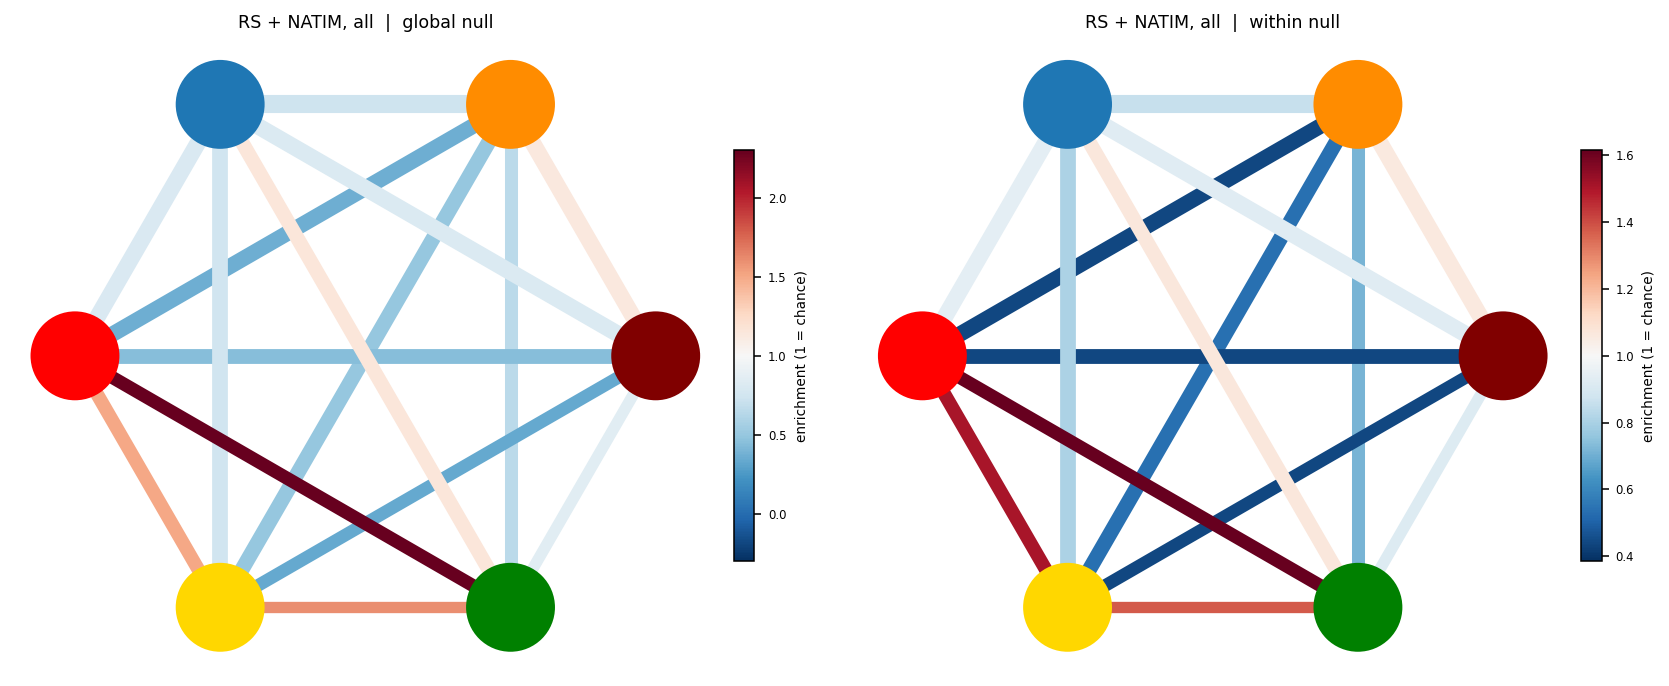

In [11]:
# pooled graphs
rows_p = [k for k in POOLED if POOLED[k].get('cond')]
fig, axes = plt.subplots(len(rows_p), len(SCOPES),
                         figsize=(6.2*len(SCOPES), 5.0*len(rows_p)), dpi=140)
axes = np.atleast_2d(axes)

for r, name in enumerate(rows_p):
    cond = POOLED[name]['cond']
    for c, scope in enumerate(SCOPES):
        ax = axes[r, c]
        if scope not in cond['tables']:
            ax.axis('off'); continue
        ed = build_edge_data(cond, scope)
        plot_graph(ed, ax, f'{name}  |  {scope} null', cond=cond,
                   width_mode=WIDTH_MODE, width_ref=WIDTH_REF)
plt.tight_layout(); plt.show()

## Fixed colorbar

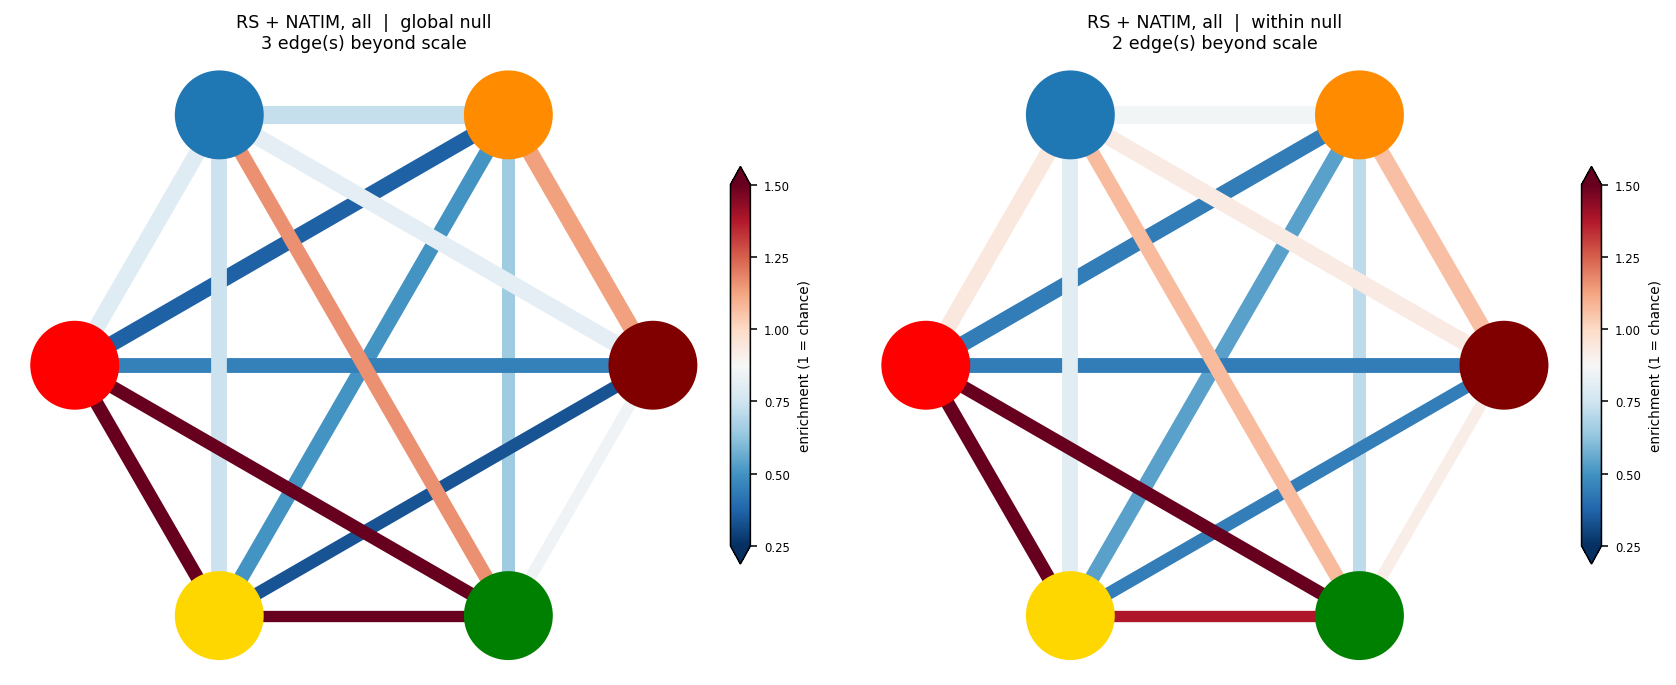

edges clipped to the colour scale limits (0.25-1.5):
                   panel           pair  enrichment
RS + NATIM, all / global NarrTRI+MedTRI       1.505
RS + NATIM, all / global    NarrTRI+Pos       2.302
RS + NATIM, all / global     MedTRI+Pos       1.610
RS + NATIM, all / within NarrTRI+MedTRI       1.509
RS + NATIM, all / within    NarrTRI+Pos       1.615


In [12]:
# ---------- POOLED GRAPHS, FIXED COLOUR SCALE ----------
VMIN, VMAX = 0.25, 1.5      # values beyond these clip to the endpoint colour

def plot_graph_fixed(edge_data, ax, title, cond,
                     vmin=VMIN, vmax=VMAX,
                     width_mode=WIDTH_MODE, width_ref=None, show_cbar=True):
    """
    As plot_graph, but with a fixed colour range and a colourbar carrying arrows
    at both ends. Enrichment outside [vmin, vmax] is drawn in the endpoint
    colour rather than rescaling the map, so panels stay comparable and a single
    extreme pair does not flatten everything else.
    """
    G = nx.Graph()
    for (u, v), (w, p, obs, exp) in edge_data.items():
        G.add_edge(u, v, weight=w, pval=p, n_close=obs,
                   raw_w=_raw_width(cond, u, v, obs, exp, width_mode))

    nodes = [c for c in FINAL_CLASSES if c in G.nodes()]
    n = len(nodes)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    radius = 0.1
    pos = {node: (radius*np.cos(a), radius*np.sin(a))
           for node, a in zip(nodes, angles)}
    node_colors = [CLASS_COLORS.get(node, 'gray') for node in nodes]

    cmap = plt.cm.RdBu_r
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)

    edges = list(G.edges())
    if width_mode == 'uniform':
        widths = [4.0] * len(edges)
    else:
        raw = np.array([G[u][v]['raw_w'] for u, v in edges], dtype=float)
        r_lo, r_hi = (raw.min(), raw.max()) if width_ref is None else width_ref
        widths = (W_MIN + (raw - r_lo) / (r_hi - r_lo) * (W_MAX - W_MIN)
                  if r_hi > r_lo else [(W_MIN + W_MAX)/2] * len(edges))

    nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=node_colors,
                           node_size=2000, ax=ax)
    cols = [cmap(norm(G[u][v]['weight'])) for u, v in edges]
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=cols,
                           width=list(widths), ax=ax)

    if show_cbar:
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, shrink=0.65, pad=0.02, extend='both')
        cbar.set_label('enrichment (1 = chance)', fontsize=7)
        cbar.set_ticks([vmin, 0.5, 0.75, 1.0, 1.25, vmax])
        cbar.ax.tick_params(labelsize=6)

    # flag edges that fall outside the displayed range
    out = [(u, v, G[u][v]['weight']) for u, v in edges
           if G[u][v]['weight'] < vmin or G[u][v]['weight'] > vmax]
    ax.set_title(title + (f'\n{len(out)} edge(s) beyond scale' if out else ''),
                 fontsize=9)
    for sp in ['right','left','top','bottom']:
        ax.spines[sp].set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.axis('equal')
    return out


pool_names = [k for k in POOLED if POOLED[k].get('cond')]
fig, axes = plt.subplots(len(pool_names), len(SCOPES),
                         figsize=(6.2*len(SCOPES), 5.0*len(pool_names)), dpi=140)
axes = np.atleast_2d(axes)

beyond = []
for r, name in enumerate(pool_names):
    cond = POOLED[name]['cond']
    for c, scope in enumerate(SCOPES):
        ax = axes[r, c]
        if scope not in cond['tables']:
            ax.axis('off'); continue
        ed = build_edge_data(cond, scope)
        out = plot_graph_fixed(ed, ax, f'{name}  |  {scope} null', cond=cond,
                               width_ref=WIDTH_REF)
        for u, v, w in out:
            beyond.append({'panel': f'{name} / {scope}',
                           'pair': f"{CLASS_DICT.get(u,u)}+{CLASS_DICT.get(v,v)}",
                           'enrichment': round(w, 3)})
plt.tight_layout(); plt.show()

if beyond:
    print(f'edges clipped to the colour scale limits ({VMIN}-{VMAX}):')
    print(pd.DataFrame(beyond).to_string(index=False))
else:
    print(f'no edges outside {VMIN}-{VMAX}')

## Enrichment matrices

Same information as a matrix, including same-class pairs which the graph cannot
show as edges. Values are enrichment; a black outline marks significance after
Holm correction. This is where significance is read, rather than in the graph.

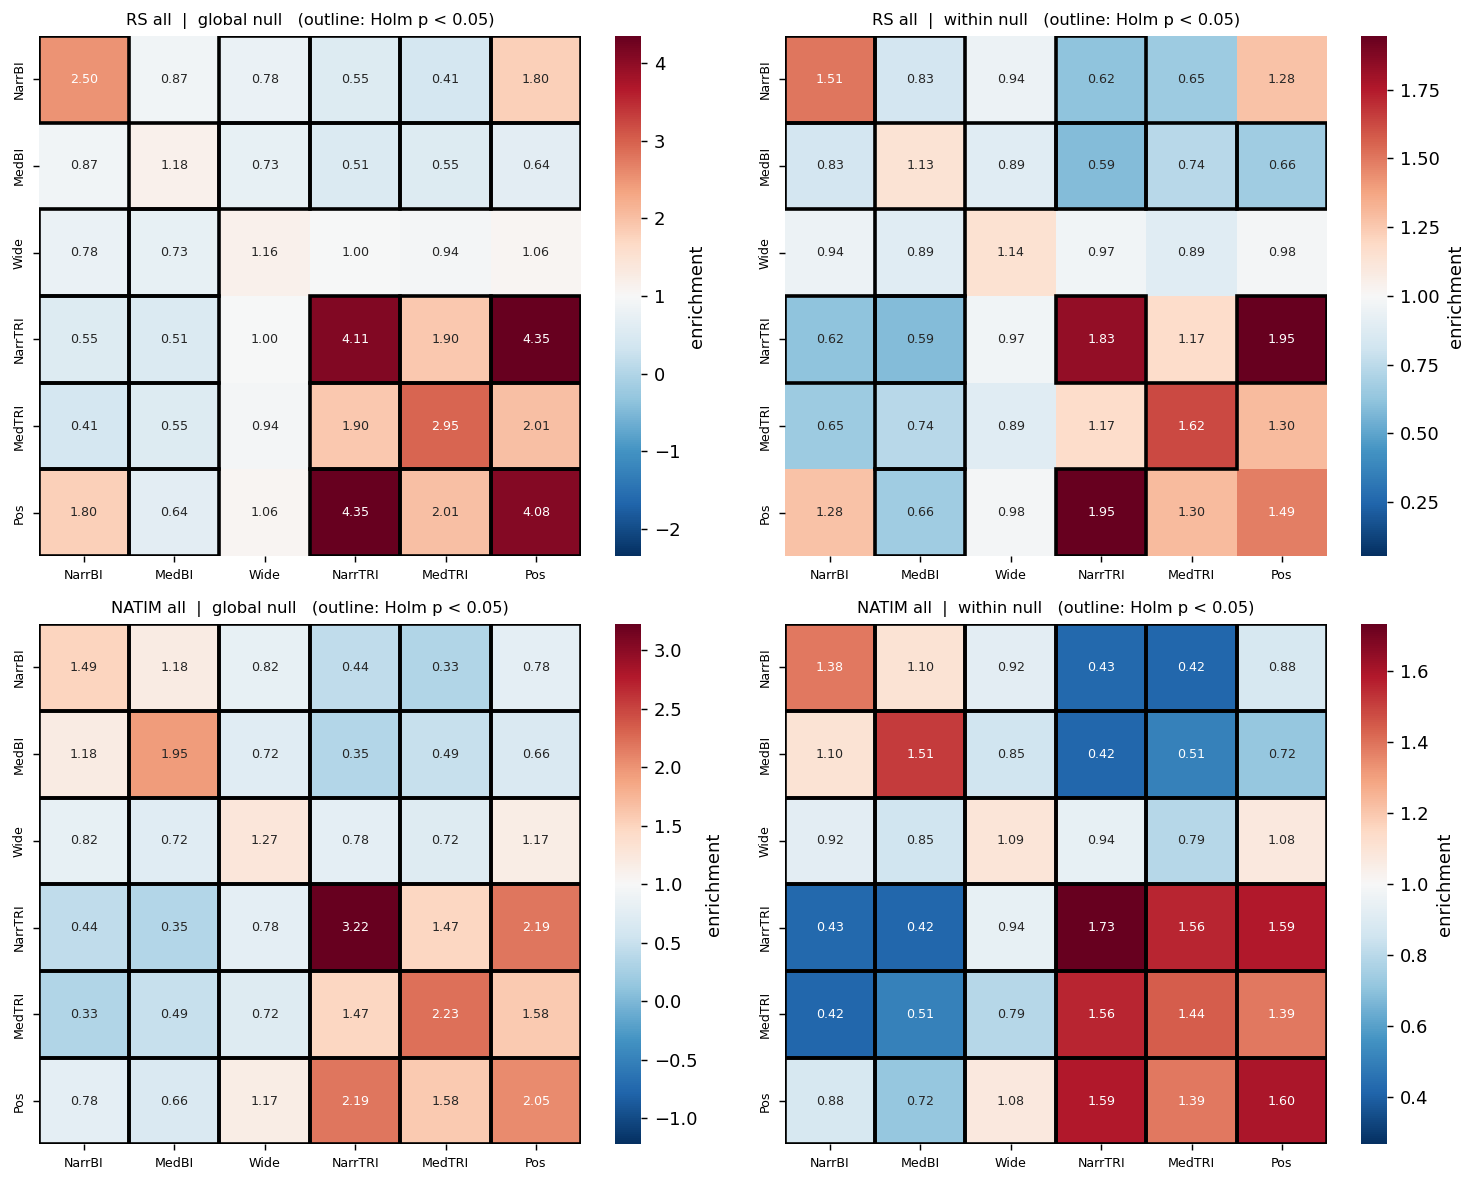

In [13]:
def enrichment_matrix(cond, scope):
    tab = cond['tables'][scope].set_index('pair')
    pcol = 'p_holm' if 'p_holm' in tab.columns else 'p_perm'
    n = len(FINAL_CLASSES)
    M = np.full((n,n), np.nan); P = np.full((n,n), np.nan); N = np.full((n,n), np.nan)
    for i, a in enumerate(FINAL_CLASSES):
        for j, b in enumerate(FINAL_CLASSES):
            key = "+".join(sorted((a,b)))
            if key in tab.index:
                M[i,j] = tab.loc[key,'enrichment']
                P[i,j] = tab.loc[key,pcol]
                N[i,j] = cond['all_pairs_count'].get(key, 0)
    return M, P, N


names = [CLASS_DICT[c] for c in FINAL_CLASSES]
fig, axes = plt.subplots(len(DATA), len(SCOPES),
                         figsize=(5.8*len(SCOPES), 4.6*len(DATA)), dpi=130)
if len(DATA) == 1: axes = np.array([axes])

for r, label in enumerate(DATA):
    for c, scope in enumerate(SCOPES):
        ax = axes[r, c]
        if scope not in DATA[label]['tables']:
            ax.axis('off'); continue
        M, P, N = enrichment_matrix(DATA[label], scope)
        span = np.nanmax(np.abs(M - 1))
        sns.heatmap(M, annot=True, fmt='.2f', annot_kws={'size':7},
                    cmap='RdBu_r', center=1, vmin=1-span, vmax=1+span,
                    xticklabels=names, yticklabels=names, ax=ax,
                    cbar_kws={'label':'enrichment'})
        for i in range(len(FINAL_CLASSES)):
            for j in range(len(FINAL_CLASSES)):
                if np.isfinite(P[i,j]) and P[i,j] < ALPHA:
                    ax.add_patch(plt.Rectangle((j,i),1,1, fill=False,
                                               edgecolor='k', lw=2))
        ax.set_title(f'{label}  |  {scope} null   (outline: Holm p < {ALPHA})',
                     fontsize=9)
        ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

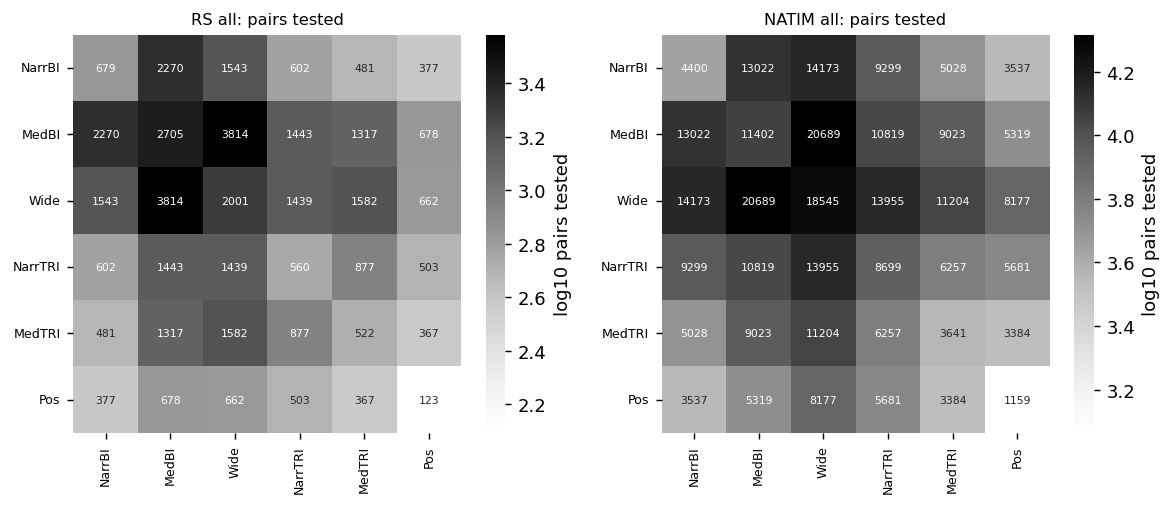

In [14]:
# how many pairs each enrichment value rests on
fig, axes = plt.subplots(1, len(DATA), figsize=(4.6*len(DATA), 4.0), dpi=130)
if len(DATA)==1: axes=[axes]
for ax, label in zip(axes, DATA):
    sc = SCOPES[0]
    if sc not in DATA[label]['tables']:
        ax.axis('off'); continue
    _, _, N = enrichment_matrix(DATA[label], sc)
    sns.heatmap(np.log10(N+1), annot=N, fmt='.0f', annot_kws={'size':6},
                cmap='Greys', xticklabels=names, yticklabels=names, ax=ax,
                cbar_kws={'label':'log10 pairs tested'})
    ax.set_title(f'{label}: pairs tested', fontsize=9)
    ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

## Comparison across conditions

In [15]:
rows = []
for label, cond in DATA.items():
    for scope in SCOPES:
        if scope not in cond['tables']: continue
        t = cond['tables'][scope]
        pcol = 'p_holm' if 'p_holm' in t.columns else 'p_perm'
        for _, r in t.iterrows():
            rows.append({'condition': label, 'scope': scope, 'pair': r['pair'],
                         'obs': r['n_close_obs'], 'exp': r['n_close_exp'],
                         'n_pairs': cond['all_pairs_count'].get(r['pair'], 0),
                         'enrichment': r['enrichment'], 'z': r['z'],
                         'p': r[pcol], 'sig': r[pcol] < ALPHA})
df_long = pd.DataFrame(rows)
df_long['pair_short'] = df_long['pair'].apply(
    lambda s: "+".join(CLASS_DICT.get(x, x) for x in s.split('+')))

for scope in SCOPES:
    sub = df_long[df_long['scope']==scope]
    if sub.empty: continue
    piv = sub.pivot(index='pair_short', columns='condition', values='enrichment')
    sig = sub.pivot(index='pair_short', columns='condition', values='sig')
    print(f'===== enrichment, {scope} null =====')
    disp = piv.round(3).astype(str)
    disp = disp.where(~sig.fillna(False), disp + ' *')
    print(disp.to_string())
    print('(* Holm p < 0.05)')
    print()

===== enrichment, global null =====
condition       NATIM all   RS all
pair_short                        
MedBI+MedBI       1.951 *  1.176 *
MedBI+MedTRI      0.491 *  0.548 *
MedBI+NarrBI       1.18 *    0.873
MedBI+NarrTRI     0.346 *  0.512 *
MedBI+Pos         0.656 *  0.642 *
MedBI+Wide        0.725 *  0.735 *
MedTRI+MedTRI     2.229 *  2.951 *
MedTRI+NarrBI     0.328 *  0.413 *
MedTRI+NarrTRI    1.471 *  1.904 *
MedTRI+Pos        1.577 *  2.009 *
MedTRI+Wide       0.717 *    0.935
NarrBI+NarrBI     1.487 *  2.498 *
NarrBI+NarrTRI    0.443 *  0.545 *
NarrBI+Pos         0.78 *  1.799 *
NarrBI+Wide       0.817 *  0.779 *
NarrTRI+NarrTRI   3.221 *  4.106 *
NarrTRI+Pos       2.194 *   4.35 *
NarrTRI+Wide      0.784 *    0.997
Pos+Pos           2.047 *  4.076 *
Wide+Pos           1.17 *    1.059
Wide+Wide         1.272 *    1.158
(* Holm p < 0.05)

===== enrichment, within null =====
condition       NATIM all   RS all
pair_short                        
MedBI+MedBI        1.51 *    1.134

In [16]:
# does filtering change the pattern, or only the power?
for scope in SCOPES:
    sub = df_long[df_long['scope']==scope]
    for rec in ['RS','NATIM']:
        a_lab, b_lab = f'{rec} all', f'{rec} filtered'
        if not {a_lab,b_lab} <= set(sub['condition']): continue
        a = sub[sub['condition']==a_lab].set_index('pair')
        b = sub[sub['condition']==b_lab].set_index('pair')
        common = a.index.intersection(b.index)
        r = np.corrcoef(a.loc[common,'enrichment'].astype(float),
                        b.loc[common,'enrichment'].astype(float))[0,1]
        flips = [(p, a.loc[p,'sig'], b.loc[p,'sig']) for p in common
                 if a.loc[p,'sig'] != b.loc[p,'sig']]
        lost = sum(1 for _, s_a, s_b in flips if s_a and not s_b)
        gained = sum(1 for _, s_a, s_b in flips if s_b and not s_a)
        print(f'{rec}, {scope} null: enrichment corr(all, filtered) = {r:.3f}')
        print(f'   significance: {lost} lost, {gained} gained')
        if r > 0.9 and gained == 0:
            print('   -> the pattern is unchanged; the losses are reduced power,'
                  ' not a change in structure')
        for p, s_a, s_b in flips:
            short = "+".join(CLASS_DICT.get(x,x) for x in p.split('+'))
            print(f'     {short:18s} {"sig" if s_a else "ns"} -> '
                  f'{"sig" if s_b else "ns"}  '
                  f'({a.loc[p,"enrichment"]:.2f} -> {b.loc[p,"enrichment"]:.2f})')
    print()

In [17]:
# which spatial scale carries the effect
for label, cond in DATA.items():
    if not set(SCOPES) <= set(cond['tables']): continue
    g = cond['tables']['global'].set_index('pair')
    w = cond['tables']['within'].set_index('pair')
    pg = 'p_holm' if 'p_holm' in g.columns else 'p_perm'
    pw = 'p_holm' if 'p_holm' in w.columns else 'p_perm'
    rows = []
    for p in g.index:
        short = "+".join(CLASS_DICT.get(x,x) for x in p.split('+'))
        sg, sw = g.loc[p,pg] < ALPHA, w.loc[p,pw] < ALPHA
        verdict = ('both scales' if sg and sw else
                   'between arrays only' if sg else
                   'local only' if sw else 'ns')
        rows.append({'pair': short,
                     'n_pairs': int(cond['all_pairs_count'].get(p, 0)),
                     'enr_global': round(g.loc[p,'enrichment'],3),
                     'enr_within': round(w.loc[p,'enrichment'],3),
                     'z_global': round(g.loc[p,'z'],2),
                     'z_within': round(w.loc[p,'z'],2),
                     'verdict': verdict})
    print(f'===== {label} =====')
    print(pd.DataFrame(rows).sort_values('z_global', ascending=False)
          .to_string(index=False))
    print()

===== RS all =====
           pair  n_pairs  enr_global  enr_within  z_global  z_within             verdict
    NarrTRI+Pos      503       4.350       1.946     17.14      8.15         both scales
NarrTRI+NarrTRI      560       4.106       1.830     16.27      7.33         both scales
  MedTRI+MedTRI      522       2.951       1.624     11.96      6.04         both scales
  NarrBI+NarrBI      679       2.498       1.509     10.41      5.39         both scales
        Pos+Pos      123       4.076       1.485      7.31      2.08 between arrays only
 MedTRI+NarrTRI      877       1.904       1.173      7.27      2.06 between arrays only
     MedTRI+Pos      367       2.009       1.303      5.44      2.20 between arrays only
     NarrBI+Pos      377       1.799       1.278      4.74      2.24 between arrays only
    MedBI+MedBI     2705       1.176       1.134      2.96      3.04 between arrays only
      Wide+Wide     2001       1.158       1.144      2.37      2.78                  ns
  

In [18]:
out_dir = f'{DF_FOLDER}/dict_pair_occur_figures'
ensure_dir_exists(out_dir)
df_long.to_csv(f'{out_dir}/enrichment_all_conditions.csv', index=False)
df_units.to_csv(f'{out_dir}/unit_counts_by_condition.csv', index=False)
print('saved to', out_dir)

saved to /CSNG/studekat/ripple_paper_clean_copy/dataframes_new_filter/dict_pair_occur_figures


## Notes

**The graph carries colour and thickness, not significance.** A strong colour on
a thin edge rests on few pairs. Significance is in the matrices and in the
comparison tables, where the pair counts sit alongside it.

**Enrichment is bounded differently in the two directions.** Depletion cannot go
below 0 while enrichment is unbounded above, so a modest blue can be as reliable
as a much redder edge. The z column in the tables is the comparable quantity.

**On filtering.** If the enrichment correlation between all and filtered is high
and every significance change is a loss, the pattern is unchanged and the losses
are reduced power from the smaller sample. The comparison cell states this
explicitly when it applies.

**On the NATIM conditions.** With around 12000 units the global test has very
large power, so almost everything separates from chance. Read the effect sizes
and the within-array column rather than the significance.

**Quality filtering removes classes unequally**, which changes the class
composition and can move enrichment by that route alone. Each condition's null
is computed on its own units so each is internally valid, but the comparison
between filtered and unfiltered is not controlled for composition. Report the
per-class retention alongside.

**Pseudoreplication.** Units recorded across sessions are treated as
independent, so counts and apparent precision are inflated. Interpret
enrichment rather than p.